In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import warnings

if '../' not in sys.path:
    sys.path.append('../')

from functools import partial
    
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp

from mcp_boltzmann import annihilation as ann
from mcp_boltzmann.boltzmann import MCPBoltzmann, ADMBoltzmann

warnings.filterwarnings("ignore")

In [3]:
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

In [4]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

### MCP model parameters

In [5]:
shelton_Q_mass_027 = load_csv('../input/fig/2206.13530_fig3_DNE_027.csv')
shelton_Q_of_M = interp1d(shelton_Q_mass_027[0], shelton_Q_mass_027[1])

In [6]:
MeV = 1
GeV = 1e3

In [7]:
# m_de = 1.526e+05*MeV
# m_dp = 1.60*10*MeV
# m_dp = 1000*m_de

m_de = 4.715e+05
m_dp = 1000*m_de


c_theta_w = 0.881255
eps_VR = 6e-9

# Q = eps_VR/c_theta_w
# Q = 6e-9
# Q = 1e-7

# Q = 4.095e-10
Q = 1.35e-5

In [8]:
print(f'{Q=}')

Q=1.35e-05


## Annihilation Collision terms

In [9]:
from mcp_boltzmann.annihilation import load_ann_rate

_CF_ff_de_de_I = load_ann_rate(
    f'../output/rates/annihilation/scan/mcp_annihilation_rate_m_{m_de}_Q_1.npz'
)

_CF_ff_dp_dp_I = load_ann_rate(
    f'../output/rates/annihilation/scan/mcp_annihilation_rate_m_{m_dp}_Q_1.npz'
)

In [10]:
#total annihilation rate from sm to dark sector
def CF_ann(T, Q):
    return Q**2*(_CF_ff_de_de_I(T) + _CF_ff_dp_dp_I(T))

def CF_ann_sm_ds(T_sm, T_ds, Q):
    return CF_ann(T_sm, Q) - CF_ann(T_ds, Q)

In [11]:
# test = np.load(f'../output/rates/coulomb/cluster/scan/mcp_coulomb_rate_m_{m_de}_Q_1.npz')
# m_de

In [12]:
# print(test['temp_grid'].min()/m_de)
# print(test['n_temps'])

## Coulomb Scattering

In [13]:
from mcp_boltzmann.elastic_scattering import load_tabulated_rate

mcp_coulomb_rate_de = load_tabulated_rate(f'../output/rates/coulomb/cluster/scan/highmass/notop/mcp_coulomb_rate_m_{m_de}_Q_1.npz')
mcp_coulomb_rate_dp = load_tabulated_rate(f'../output/rates/coulomb/cluster/scan/highmass/notop/mcp_coulomb_rate_m_{m_dp}_Q_1.npz')
# mcp_coulomb_rate_F = load_tabulated_rate(f'../output/rates/coulomb/cluster/scan/mcp_coulomb_rate_m_{m_de}_Q_1_F.npz')

In [14]:
@np.vectorize
def CF_scatt_sm_ds(T_sm, T_ds, Q):
    if(T_sm == T_ds):
        return 0.0
    return Q**2*(mcp_coulomb_rate_de(T_sm, T_ds) + mcp_coulomb_rate_dp(T_sm, T_ds))

def CF_scatt_sm_ds_F(T_sm, T_ds, Q):
    return Q**2*mcp_coulomb_rate_F(T_sm, T_ds)

## Plasmon Decay

In [15]:
from mcp_boltzmann import plasma as plas
def CF_plas(T_sm, T_ds, Q):
    T_EW = 160*GeV
    
    pdecay_de = np.heaviside(T_EW - T_sm, 0)*plas.C_plasmon(T_sm, T_ds, m_de, Q) 
    bdecay_de = np.heaviside(T_sm - T_EW, 1)*plas.C_B_decay(T_sm, T_ds, m_de, Q)

    pdecay_dp = np.heaviside(T_EW - T_sm, 0)*plas.C_plasmon(T_sm, T_ds, m_dp, Q) 
    bdecay_dp = np.heaviside(T_sm - T_EW, 1)*plas.C_B_decay(T_sm, T_ds, m_dp, Q)
    
    return pdecay_de + bdecay_de + pdecay_dp + bdecay_dp

### Z decay

In [16]:
def CF_Z_decay(T_sm, T_ds, Q):
    return plas.C_Z_decay(T_sm, T_ds, m_de, Q) + plas.C_Z_decay(T_sm, T_ds, m_dp, Q) 

# Setup Boltzmann equation

In [17]:
Boltz = ADMBoltzmann(m_de, m_dp, Q, rtol=1e-8, atol=1e-8)
Boltz.add_colterm_EM_DS(CF_ann_sm_ds)
Boltz.add_colterm_EM_DS(CF_scatt_sm_ds)
Boltz.add_colterm_EM_DS(CF_plas)
Boltz.add_colterm_EM_DS(CF_Z_decay)

In [18]:
T_gamma_0 = 100*m_dp
T_nu_0 = T_gamma_0
T_DS_0 = 1e4
# T_DS_0 = 1e6

In [19]:
T_DS_test = np.geomspace(1e-4, 1.1)*T_gamma_0

R = 4*Boltz.Hubble(T_gamma_0, T_gamma_0, T_DS_test)*Boltz.rho_DS(T_DS_test)/np.abs(Boltz.colterm_EM_DS(T_gamma_0, T_DS_test))
T_DS_0=1e-2*T_DS_test[find_nearest(np.log(R), 0)]
print(f'{T_DS_0=:.3e}')

T_DS_0=4.392e+07


In [20]:
1e-2*T_DS_test[find_nearest(np.log(R), 0)]/T_gamma_0

0.0009315077286696504

In [21]:
T_DS_0 = T_gamma_0

In [22]:
sol_sm = Boltz.solve_boltzmann_eq_SM(T_gamma_0, T_gamma_0)

time_sm = sol_sm[0]
T_gam_sm = sol_sm[1]
T_nu_sm = sol_sm[2]
sf_sm = sol_sm[3]

Boltz.N_eff_SM(T_gam_sm[-1], T_nu_sm[-1])

3.008751986243093

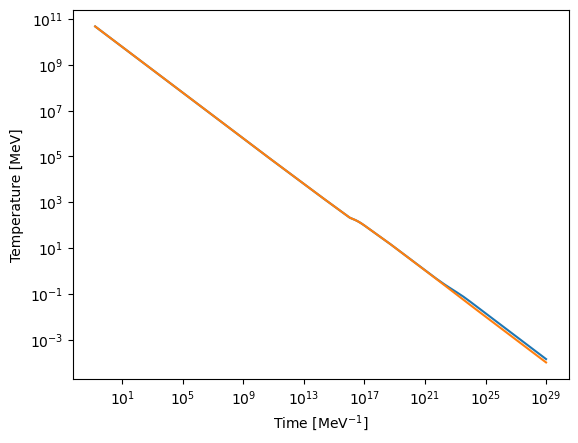

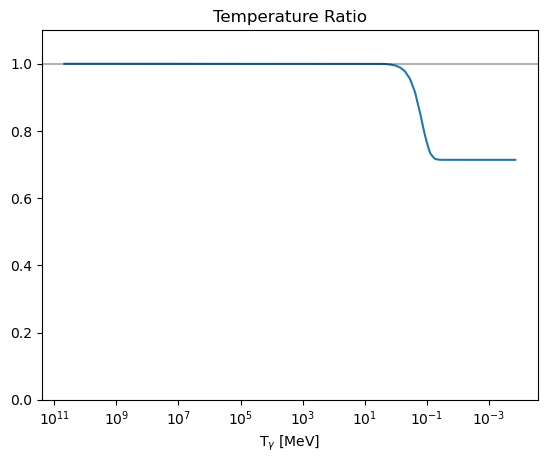

In [23]:
plt.plot(time_sm, T_gam_sm)
plt.plot(time_sm, T_nu_sm)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Time [MeV$^{-1}$]')
plt.ylabel('Temperature [MeV]')

plt.show()

plt.plot(T_gam_sm, T_nu_sm/T_gam_sm)
plt.xscale('log')
# plt.yscale('log')
plt.axhline(1.0, color='black', alpha=0.3)
plt.xlabel(r'T$_\gamma$ [MeV]')
plt.title('Temperature Ratio')
plt.ylim(0, 1.1)

plt.gca().invert_xaxis()
plt.show()

In [24]:
sol_bsm = Boltz.solve_boltzmann_eq_L(T_gamma_0, T_nu_0, T_DS_0)

time_bsm = sol_bsm[0]
T_gam_bsm = sol_bsm[1]
T_nu_bsm = sol_bsm[2]
T_dark_bsm = sol_bsm[3]
sf_bsm = sol_bsm[4]

## Neff

In [25]:
N_eff_bsm = Boltz.N_eff(T_gam_bsm[-1], T_nu_bsm[-1], T_dark_bsm[-1])
N_eff_sm = Boltz.N_eff_SM(T_gam_sm[-1], T_nu_sm[-1])

DeltaN_eff_dso = Boltz.Delta_Neff_ds_only(T_gam_bsm[-1], T_dark_bsm[-1])
Delta_Neff = N_eff_bsm - N_eff_sm 

In [26]:
print(f'{N_eff_sm=}')
print(f'{N_eff_bsm=}')
print(f'{Delta_Neff=}')

print(f'{DeltaN_eff_dso=}')

print(f'{T_dark_bsm[-1]/T_gam_bsm[-1]=}')
print(f'{T_nu_bsm[-1]/T_gam_bsm[-1]=}')

print(f'{T_gam_bsm[-1]/T_gam_sm[-1]=}')

N_eff_sm=3.008751986243093
N_eff_bsm=array([3.08078687])
Delta_Neff=array([0.07203489])
DeltaN_eff_dso=array([0.07196286])
T_dark_bsm[-1]/T_gam_bsm[-1]=0.3575484328634504
T_nu_bsm[-1]/T_gam_bsm[-1]=0.7142901345089445
T_gam_bsm[-1]/T_gam_sm[-1]=0.9975850343268214


In [27]:
T_dark_bsm[-1]

5.04751175949181e-05

In [28]:
print(f'{m_de:.3e}')
print(f'{m_dp:.3e}')

4.715e+05
4.715e+08


## Temperature Evolution

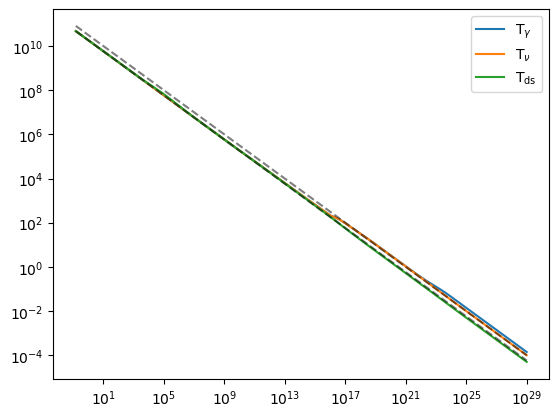

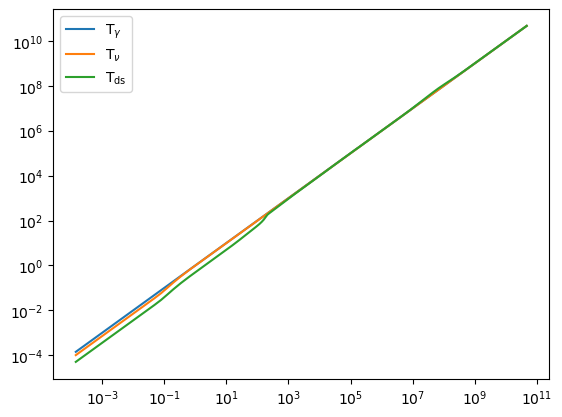

In [29]:
plt.plot(time_bsm, T_gam_bsm, label=r'T$_\gamma$')
plt.plot(time_bsm, T_nu_bsm, label=r'T$_{\nu}$')
plt.plot(time_bsm, T_dark_bsm, label=r'T$_{\rm ds}$')

plt.plot(time_bsm, T_gam_bsm[0]*np.sqrt(time_bsm[0]/time_bsm), linestyle='dashed', color='black', alpha=0.5)
plt.plot(time_bsm, T_nu_bsm[-1]*np.sqrt(time_bsm[-1]/time_bsm), linestyle='dashed', color='black', alpha=0.5)

plt.yscale('log')
plt.xscale('log')

plt.legend()

plt.show()


plt.plot(T_gam_bsm, T_gam_bsm, label=r'T$_\gamma$')
plt.plot(T_gam_bsm, T_nu_bsm, label=r'T$_{\nu}$')
plt.plot(T_gam_bsm, T_dark_bsm, label=r'T$_{\rm ds}$')


plt.yscale('log')
plt.xscale('log')

plt.legend()

plt.show()


In [30]:
# fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig3_left_Td_by_Tgam.csv')
# fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig3_right_Td_by_Tgam.csv')
# fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig4_left_Td_by_Tgam.csv')
# fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig4_right_Td_by_Tgam.csv')
# fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig5_left_Td_by_Tgam.csv')
fig3_1311_2600_Td_by_Tgam = load_csv('../input/fig/1311.2600_fig5_right_Td_by_Tgam.csv')

# fig3_1311_2600_Tnu_by_Tgam = load_csv('../input/fig/1311.2600_fig4_right_Tnu_by_Tgam.csv')
# fig3_1311_2600_Tnu_by_Tgam = load_csv('../input/fig/1311.2600_fig5_left_Tnu_by_Tgam.csv')
# fig3_1311_2600_Tnu_by_Tgam = load_csv('../input/fig/1311.2600_fig5_left_Tnu_by_Tgam.csv')

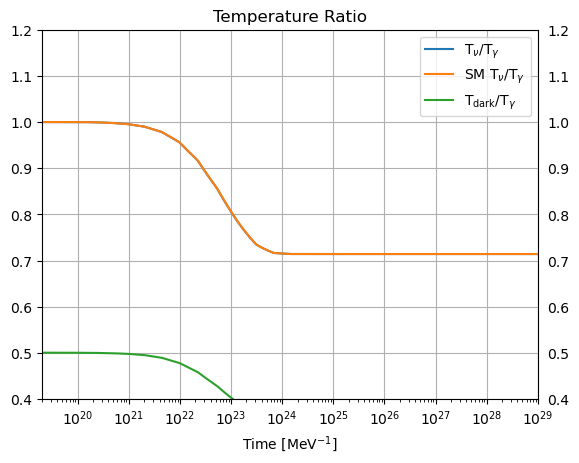

In [31]:
plt.plot(time_bsm, T_nu_bsm/T_gam_bsm, label=r'T$_\nu$/T$_\gamma$')
plt.plot(time_sm, T_nu_sm/T_gam_sm, label=r'SM T$_\nu$/T$_\gamma$')
plt.plot(time_bsm, T_dark_bsm/T_gam_bsm, label=r'T$_{\rm dark}$/T$_\gamma$')
plt.xscale('log')
# plt.yscale('log')

plt.xlabel('Time [MeV$^{-1}$]')
plt.title('Temperature Ratio')

plt.tick_params(labelright=True, which='both')
plt.yticks()
plt.grid(which='both', axis='y')
plt.grid(axis='x')

plt.legend()

plt.xlim(2e19, 1e29)
plt.ylim(0.4, 1.2)

plt.show()



Text(0.5, 0, 'Time [MeV$^{-1}$]')

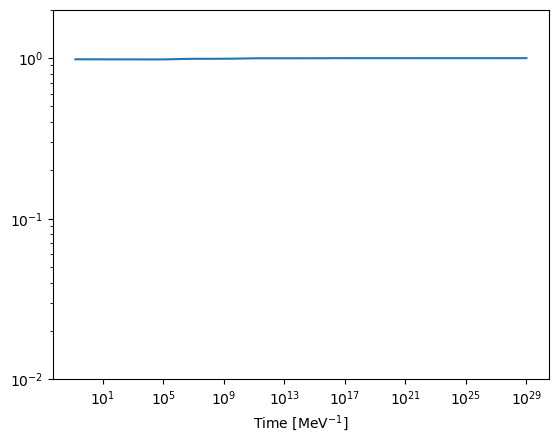

In [32]:
from scipy.interpolate import interp1d
T_gam_SM_I = interp1d(time_sm, T_gam_sm)
T_gam_BSM_I = interp1d(time_bsm, T_gam_bsm)

plt.plot(time_sm, T_gam_BSM_I(time_sm)/T_gam_SM_I(time_sm))
plt.ylim(1e-2, 2)

plt.yscale('log')
plt.xscale('log')
plt.xlabel('Time [MeV$^{-1}$]')


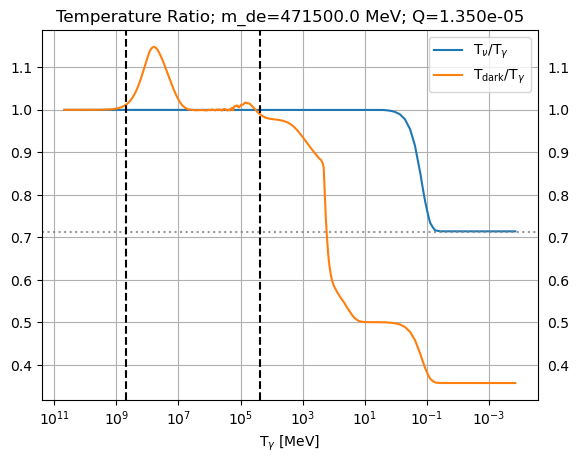

In [33]:
plt.plot(T_gam_bsm, T_nu_bsm/T_gam_bsm, label=r'T$_\nu$/T$_\gamma$')
plt.plot(T_gam_bsm, T_dark_bsm/T_gam_bsm, label=r'T$_{\rm dark}$/T$_\gamma$')
# plt.plot(*fig3_1311_2600_Td_by_Tgam, label='Vogel & Redondo')
# plt.plot(*fig3_1311_2600_Tnu_by_Tgam, label='Vogel & Redondo - neutrinos')
plt.xscale('log')
# plt.yscale('log')

plt.xlabel('T$_\gamma$ [MeV]')
plt.title(f'Temperature Ratio; {m_de=} MeV; {Q=:.3e}')

plt.tick_params(labelright=True, which='both')
plt.yticks()
plt.grid(which='both', axis='y')
plt.grid(axis='x')
plt.gca().invert_xaxis()


# plt.ylim(0.6, 1.3)
# plt.axvline(200,  color='purple', linestyle='dashed', alpha=0.5, label=r'$\Lambda_{\rm QCD}$')
# plt.axvline(150,  color='purple', linestyle='dashed', alpha=0.5)

plt.axhline((4/11)**(1/3), alpha=0.8, color='gray', linestyle='dotted')
plt.axvline(m_de/20, linestyle='dashed', color='black')
plt.axvline(m_dp, linestyle='dashed', color='black')

# plt.axhline(0.56, alpha=0.8, color='gray', linestyle='dotted')
# plt.axhline(0.46, alpha=0.8, color='gray', linestyle='dotted')

# plt.xlim(1e2, 1.1e-2)
plt.legend()

# plt.savefig('../output/figures/temp_ratio/m_03_eps_6e-9_VR_comparison.png')

plt.show()

In [34]:
Col_tot = (
    CF_ann_sm_ds(T_gam_bsm, T_dark_bsm, Q)
   +CF_plas(T_gam_bsm, T_dark_bsm, Q)
)

Hub_tot = Boltz.Hubble(T_gam_bsm, T_nu_bsm,T_dark_bsm)*(
    Boltz.rho_DS(T_dark_bsm) + Boltz.p_DS(T_dark_bsm)
)
            

In [35]:
com_ED = Boltz.rho_DS(T_dark_bsm)*(sf_bsm)**4

com_col = (
   +CF_ann(T_gam_bsm, Q)
   +plas.C_plasmon_forwards(T_gam_bsm, m_de, Q)
)*(sf_bsm)**4

H_plot = Boltz.Hubble(T_gam_bsm, T_nu_bsm, T_dark_bsm)

In [36]:
# shelton_f2_rho = load_csv('../input/fig/2206.13530_fig2_left_energy.csv')
# shelton_f2_cF = load_csv('../input/fig/2206.13530_fig2_left_CF.csv')

shelton_f2_rho = load_csv('../input/fig/2206.13530_fig2_right_energy.csv')
# shelton_f2_cF = load_csv('../input/fig/2206.13530_fig2_left_CF.csv')

## We need to plot the forward energy transfer term here, which needs to be computed for elastic scattering

In [37]:
#compute comoving energy density for DeltaNeff = 0.3s

In [38]:
#calculation of dark sector temp that makes Delta N_eff = 0.3 at Tsm = 1e-3 MeV
r = 0.3*(7/8)*(4/11)**(4/3)*Boltz.rho_EM(1e-3)
T_ds_03 = ((15/np.pi**2)*r)**(1/4)

sf = sf_bsm[find_nearest(T_gam_bsm, 1e-3)]

rho_neff_03 = Boltz.rho_DS(T_ds_03)*(sf)**4

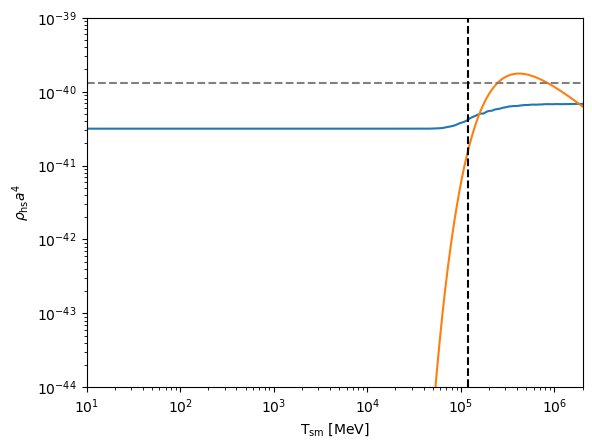

In [39]:
plt.plot(T_gam_bsm, com_ED)
plt.plot(T_gam_bsm, com_col/H_plot)
# plt.plot(*shelton_f2_rho)
# plt.plot(*shelton_f2_cF)

# plt.axhline(rho_neff_03, label=r'$\Delta N_{\rm eff} = 0.3$', linestyle='dashed')
plt.axhline(1.3e-40, label=r'$\Delta N_{\rm eff} = 0.3$', linestyle='dashed', color='gray')

plt.yscale('log')
plt.xscale('log')
plt.axvline(m_de/4, linestyle='dashed', color='black')

plt.xlabel(r'T$_{\rm sm}$ [MeV]')
plt.ylabel(r'$\rho_{\rm hs} a^4$')

plt.ylim(1e-44, 1e-39)
# plt.xlim(3, 1e4)
plt.xlim(10, 2e6)
plt.show()

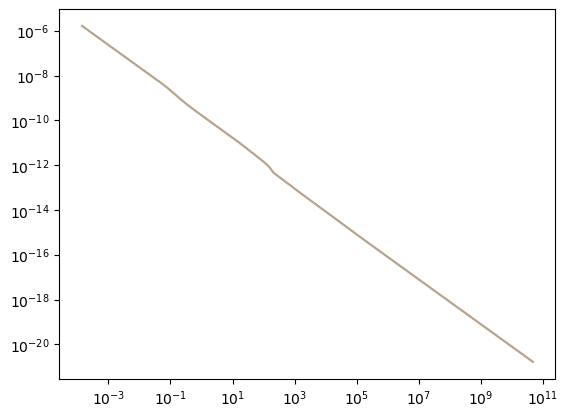

In [40]:
plt.plot(T_gam_bsm, sf_bsm, alpha=0.5)
plt.plot(T_gam_sm, sf_sm, alpha=0.4)


plt.yscale('log')
plt.xscale('log')

## Check Continuity

In [41]:
def C_forward_de(T, Q):
    return Q**2*(_CF_ff_de_de_I(T))

def C_forward_dp(T, Q):
    return Q**2*(_CF_ff_dp_dp_I(T))

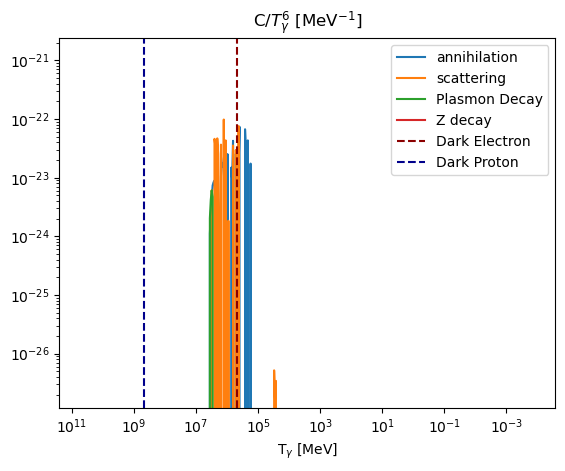

In [42]:
plt.plot(T_gam_bsm, Boltz.colterms_EM_DS[0](T_gam_bsm, T_dark_bsm, Q)/T_gam_bsm**6, label='annihilation')
plt.plot(T_gam_bsm, Boltz.colterms_EM_DS[1](T_gam_bsm, T_dark_bsm, Q)/T_gam_bsm**6, label='scattering')
plt.plot(T_gam_bsm, Boltz.colterms_EM_DS[2](T_gam_bsm, T_dark_bsm, Q)/T_gam_bsm**6, label='Plasmon Decay')
plt.plot(T_gam_bsm, Boltz.colterms_EM_DS[3](T_gam_bsm, T_dark_bsm, Q)/T_gam_bsm**6, label='Z decay')

sum_rate = (
    Boltz.colterms_EM_DS[0](T_gam_bsm, T_dark_bsm, Q)
    +Boltz.colterms_EM_DS[1](T_gam_bsm, T_dark_bsm, Q)
    +Boltz.colterms_EM_DS[2](T_gam_bsm, T_dark_bsm, Q)
    +Boltz.colterms_EM_DS[3](T_gam_bsm, T_dark_bsm, Q)
)

ymax = np.max(sum_rate/T_gam_bsm**6)

plt.axvline(m_de, label='Dark Electron', linestyle='dashed', color='darkred')
plt.axvline(m_dp, label='Dark Proton', linestyle='dashed', color='darkblue')



plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-5*ymax, 20*ymax)
plt.gca().invert_xaxis()

plt.xlabel(r'T$_\gamma$ [MeV]')
plt.title(r'C/$T^6_\gamma$ [MeV$^{-1}$]')
plt.legend()

In [43]:
Boltz.colterms_EM_DS[3](T_gam_bsm, T_dark_bsm, Q)/T_gam_bsm**6

array([-0.,  0.,  0., ..., -0., -0., -0.])

In [44]:
m_de

471500.0

In [45]:
91188.0  - m_de

-380312.0

In [46]:
Boltz.colterms_EM_DS[1](1e5, 1e5, Q)

array(0.)

In [47]:
m_de

471500.0

In [48]:
np.sqrt(plas.m_B_2(1e6))/1e6

0.3290401380976521

In [49]:
plas.C_B_decay(1e6, 1e3, 1e6, 1e-10)

-0.0

In [50]:
np.heaviside(1 - 4*(1e6)**2/plas.m_B_2(1e6), 0)

0.0

In [51]:
Boltz.colterms_EM_DS[1](1e8, 1e8, Q)

array(0.)

In [52]:
test_x

NameError: name 'test_x' is not defined